# Исследовательский анализ данных (EDA)
Датасет: Titanic

Цель: Понять структуру датасета и его ключевые паттерны 

In [51]:
import matplotlib.pyplot as plt
import pandas as pd


X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')

X_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
print(X_train.shape)
print(X_train.info())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


- Датасет содержит 891 строк и 12 столбцов
- В нем есть как числовые, так и категориальные признаки

In [53]:
X_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- Возраст и стоимость билета имеют широкий диапазон

In [54]:
print(X_train.isnull().sum(), '\n\n')
print(X_test.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


- Признаки age, cabin содержат пропуски в обеих выборках
- Требуется обработка пропущенных значений

In [55]:
X_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

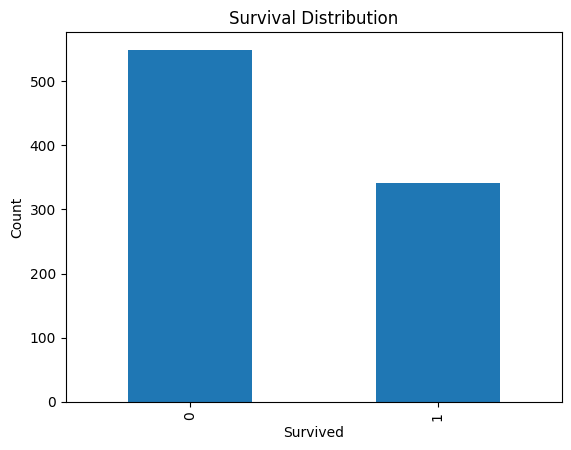

In [59]:
X_train['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Distribution')
plt.xlabel("Survived")
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Survived'>

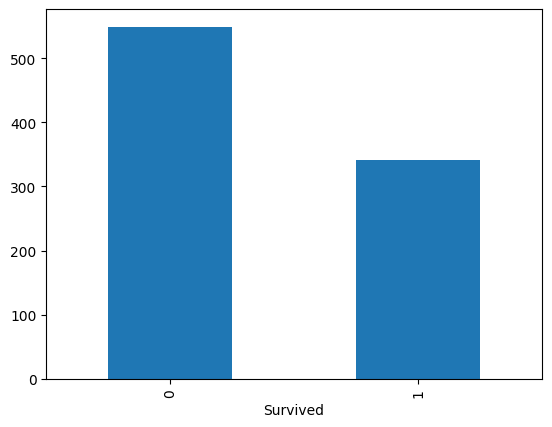

In [56]:
X_train['Survived'].value_counts().plot(kind='bar')

- Целевая переменная имеет умеренный дисбаланс

In [63]:
X_train['Age'].value_counts().to_dict()

{24.0: 30,
 22.0: 27,
 18.0: 26,
 28.0: 25,
 30.0: 25,
 19.0: 25,
 21.0: 24,
 25.0: 23,
 36.0: 22,
 29.0: 20,
 32.0: 18,
 26.0: 18,
 35.0: 18,
 27.0: 18,
 31.0: 17,
 16.0: 17,
 23.0: 15,
 20.0: 15,
 34.0: 15,
 33.0: 15,
 39.0: 14,
 42.0: 13,
 17.0: 13,
 40.0: 13,
 45.0: 12,
 38.0: 11,
 2.0: 10,
 50.0: 10,
 4.0: 10,
 48.0: 9,
 47.0: 9,
 44.0: 9,
 54.0: 8,
 9.0: 8,
 51.0: 7,
 1.0: 7,
 37.0: 6,
 14.0: 6,
 52.0: 6,
 41.0: 6,
 49.0: 6,
 3.0: 6,
 58.0: 5,
 15.0: 5,
 43.0: 5,
 5.0: 4,
 8.0: 4,
 11.0: 4,
 56.0: 4,
 60.0: 4,
 62.0: 4,
 61.0: 3,
 6.0: 3,
 46.0: 3,
 65.0: 3,
 7.0: 3,
 13.0: 2,
 55.0: 2,
 70.0: 2,
 57.0: 2,
 30.5: 2,
 32.5: 2,
 71.0: 2,
 40.5: 2,
 59.0: 2,
 0.83: 2,
 28.5: 2,
 10.0: 2,
 0.75: 2,
 64.0: 2,
 63.0: 2,
 45.5: 2,
 66.0: 1,
 55.5: 1,
 70.5: 1,
 12.0: 1,
 14.5: 1,
 36.5: 1,
 20.5: 1,
 0.92: 1,
 23.5: 1,
 53.0: 1,
 80.0: 1,
 24.5: 1,
 0.67: 1,
 0.42: 1,
 34.5: 1,
 74.0: 1}

<Axes: >

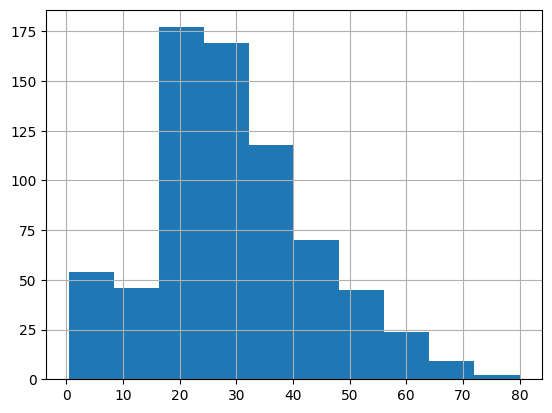

In [58]:
X_train['Age'].hist()

- Количество молодых пассажиров больше всех остальных

In [60]:
X_train.groupby(['Sex'])['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

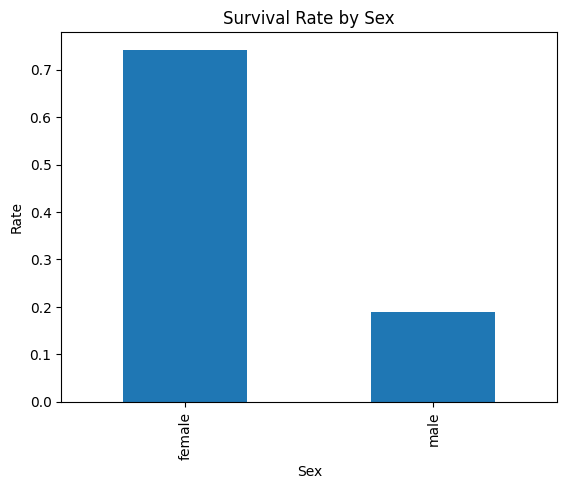

In [61]:
X_train.groupby(['Sex'])['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.ylabel('Rate')
plt.show()

- Женщин в выборке выживало в среднем значительно больше, чем мужчин

# Вывод
- Есть пропуски в данных
- Целевая переменная не сбалансированна
- Некоторые признаки явно информативны
